## Imports and parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path

r_values = [0.6, 0.7, 0.8, 0.9]
perimeters = [50, 100, 200, 500, 1000, 2000]

## Load data from h5 files

In [6]:
def coefficient_file(r, m):
    """
    Find the coefficient file corresponding to effective radius r and
    half-perimeter h.

    Returns
    -------
    pathlib.Path or None
        Path to the coefficient file if it exists, otherwise None
    """

    radius_tag = f"{r:g}"

    path = Path(f"data/coefficients_r{radius_tag}_m{m}.h5")

    if path.exists():
        return path

    return None

def load_coefficient_data(r_values=r_values, perimeters=perimeters):
    """
    Load all available coefficient ensembles for the requested effective
    radii and disk sizes.

    Each ensemble contains the fitted polynomial coefficients, residuals,
    fitting radius, disk size, and polynomial degree. Missing combinations
    are reported.

    Returns
    -------
    dict
        Dictionary indexed by (r, h), containing the data for each ensemble
    """

    data = {}

    for r in r_values:
        for m in perimeters:

            path = coefficient_file(r, m)

            if path is None:
                continue

            with h5py.File(path, "r") as f:

                coefficients = f["coefficients"][:]
                residuals = f["residuals"][:]

                data[(r, m)] = {
                    "coefficients": coefficients,
                    "residuals": residuals,
                    "r": float(f.attrs.get("fit_radius", r)),
                    "m": m,
                    "degree": coefficients.shape[1] - 1
                }

    if not data:
        raise FileNotFoundError(
            f"No coefficient files found in {DATA_DIR.resolve()}"
        )

    missing = [
        (r, m)
        for r in r_values
        for m in perimeters
        if (r, m) not in data
    ]

    if missing:
        print(f"Note: {len(missing)} (r, m) combinations are missing: ", f"{missing}")

    return data

data = load_coefficient_data()

## Helper functions - computing the Fourier modes

In [8]:
def derivative_coefficients(coefficients):
    """
    Compute the polynomial coefficients of F'(z) from those of F(z).

    Returns
    -------
    np.ndarray
        Coefficients of the derivative polynomial
    """

    powers = np.arange(1, coefficients.shape[-1])

    return coefficients[..., 1:] * powers


def smallest_zero_modulus(coefficients):
    """
    Find the distance from the origin to the closest zero of a polynomial.
    If the polynomial is constant, infinity is returned.

    Returns
    -------
    float
        Modulus of the zero closest to the origin
    """

    roots = np.roots(coefficients[::-1])

    if roots.size == 0:
        return np.inf

    return float(np.min(np.abs(roots)))


def log_taylor_coefficients(derivative_coeffs):
    """
    Compute the Taylor coefficients of log F'(z).

    For F'(z) = b_0 + b_1 z + ...
    write log F'(z) = c_0 + c_1 z + ...

    The coefficients are obtained recursively from
    (log F')' F' = F''

    Comparing the coefficient of z^(n-1) gives
    n c_n b_0 = n b_n - sum_{k=1}^{n-1} k c_k b_{n-k}

    Returns
    -------
    np.ndarray
        Complex Taylor coefficients c_0, ..., c_{d-1}
    """

    c = np.zeros(len(derivative_coeffs), dtype=complex)
    c[0] = np.log(complex(derivative_coeffs[0]))

    for n in range(1, len(derivative_coeffs)):
        value = n * derivative_coeffs[n]

        for k in range(1, n):
            value -= (
                k
                * c[k]
                * derivative_coeffs[n - k]
            )

        c[n] = value / (n * derivative_coeffs[0])

    return c


def boundary_modes(entry):
    """
    Compute the harmonically extrapolated boundary Fourier modes.

    For each fitted conformal map, the Taylor coefficients c_n of log F'
    determine the positive Fourier modes of

        sigma(theta) = log |F'(e^(i theta))|

    according to

        sigmahat_n = c_n / 2

    Only maps for which F' has no zero inside the fitted disk |z| <= r
    are marked as admissible, since log F' must be holomorphic there.

    Returns
    -------
    sigmahat : np.ndarray
        Boundary Fourier modes with shape (n_disks, n_modes)

    admissible : np.ndarray
        Boolean array indicating which disks have zero-free F' on |z| <= r
    """

    derivative_coeffs = derivative_coefficients(
        entry["coefficients"]
    )

    n_disks, n_coeffs = derivative_coeffs.shape
    sigmahat = np.zeros((n_disks, n_coeffs - 1), dtype=complex)
    admissible = np.zeros(n_disks, dtype=bool)

    for i in range(n_disks):

        admissible[i] = (smallest_zero_modulus(derivative_coeffs[i]) > entry["r"])
        log_coeffs = log_taylor_coefficients(derivative_coeffs[i])
        sigmahat[i] = 0.5 * log_coeffs[1:]

    return sigmahat, admissible
    

def mode_power(modes, mask=None):
    """
    Compute the ensemble mean power of each Fourier mode.
    If a Boolean mask is supplied, only the selected realizations are used.

    Returns
    -------
    mean_power : np.ndarray
        Ensemble mean of |X_n|^2 for each mode

    """

    if mask is not None:
        modes = modes[mask]

    power = np.abs(modes) ** 2
    mean_power = power.mean(axis=0)

    return mean_power

## Helper functions - plotting

In [7]:
def plot_coefficients_vs_radius(ax, data, m, r_values=r_values):
    """
    Plot the ensemble mean coefficient magnitudes as a function of the
    effective fitting radius for one disk size.
    """

    radii = [r for r in r_values if (r, m) in data]

    if not radii:
        return

    mean_coefficients = np.array([np.abs(data[(r, m)]["coefficients"]).mean(axis=0) for r in radii])

    for k in range(mean_coefficients.shape[1]):
        ax.plot(radii, mean_coefficients[:, k], "o-", ms=3.5, lw=1, label=rf"$a_{{{k}}}$")

    ax.set_yscale("log")
    ax.set_xlabel("effective radius $r$")
    ax.set_ylabel(r"mean $|a_k|$")
    ax.set_title(rf"$m \approx {m}$", fontsize=9)


def plot_coefficients_vs_perimeter(ax, data, r, perimeters=perimeters):
    """
    Plot the ensemble mean coefficient magnitudes as a function of disk
    perimeter for one effective fitting radius.
    """

    perimeters_available = [m for m in perimeters if (r, m) in data]

    if not perimeters_available:
        return

    mean_coefficients = np.array([
        np.abs(data[(r, m)]["coefficients"]).mean(axis=0)
        for m in perimeters_available])

    for k in range(mean_coefficients.shape[1]):

        ax.plot(perimeters_available, mean_coefficients[:, k], "o-", ms=3.5,
            lw=1, label=rf"$a_{{{k}}}$")

    ax.set_xscale("log")
    ax.set_xlabel("disk perimeter $m$")
    ax.set_ylabel(r"mean $|a_k|$")
    ax.set_title(rf"$r = {r}$", fontsize=9)


def plot_coefficient_magnitudes(data, m_small, m_large, r_small, r_large):
    """
    Plot the mean magnitudes of the fitted conformal-map coefficients
    as functions of effective radius and disk perimeter.

    The top row compares the radius dependence for a small and a large
    disk. The bottom row compares the perimeter dependence for a small
    and a large effective radius.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Generated figure

    axes : np.ndarray
        Array containing the four plot axes
    """

    fig, axes = plt.subplots(2, 2, figsize=(7.6, 5.6))

    # dependence on effective radius
    plot_coefficients_vs_radius(axes[0, 0], data, m_small)
    plot_coefficients_vs_radius(axes[0, 1], data, m_large)

    # dependence on disk perimeter
    plot_coefficients_vs_perimeter(axes[1, 0], data, r_small)
    plot_coefficients_vs_perimeter(axes[1, 1], data, r_large)

    # panel labels
    for ax, label in zip(axes.ravel(), "abcd"):
        ax.text(-0.16, 1.04, f"({label})", transform=ax.transAxes, fontweight="bold")

    axes[0, 0].legend(ncol=3, loc="best")

    fig.tight_layout()
    plt.show()

    return fig, axes


def plot_residual_vs_radius(data, m_fixed):
    """
    Plot the mean fitting residual as a function of the effective radius
    for a fixed disk size.
    """

    radii = [r for r in r_values if (r, m_fixed) in data]

    mean_residuals = [data[(r, m_fixed)]["residuals"].mean() for r in radii]
    std_residuals = [data[(r, m_fixed)]["residuals"].std() for r in radii]

    fig, ax = plt.subplots(figsize=(4.2, 3.2))

    ax.errorbar(radii, mean_residuals, yerr=std_residuals, fmt="o-", ms=4, lw=1, capsize=3)

    ax.set_xlabel("effective radius $r$")
    ax.set_ylabel("fit residual")

    fig.tight_layout()
    plt.show()

def plot_residual_vs_perimeter(data, r_fixed):
    """
    Plot the mean fitting residual as a function of disk perimeter for a
    fixed effective radius.
    """

    sizes = [m for m in perimeters if (r_fixed, m) in data]

    mean_residuals = [data[(r_fixed, m)]["residuals"].mean() for m in sizes]
    std_residuals = [data[(r_fixed, m)]["residuals"].std() for m in sizes]

    fig, ax = plt.subplots(figsize=(4.2, 3.2))

    ax.errorbar(sizes, mean_residuals, yerr=std_residuals, fmt="o-", ms=4, lw=1, capsize=3)

    ax.set_xscale("log")
    ax.set_xlabel("disk perimeter $m$")
    ax.set_ylabel("fit residual")

    fig.tight_layout()
    plt.show()


def plot_mode_power_vs_size(data, r_fixed, n_max=7, gff_constant=0.25):
    """
    Plot the extrapolated Fourier-mode power at a fixed effective radius
    for different disk sizes.

    For each disk size, the quantity

        n E[|sigmahat_n|^2]

    is plotted as a function of the Fourier mode n. For the GFF prediction,
    this quantity is expected to be independent of n.
    """

    sizes = [m for m in perimeters if (r_fixed, m) in data]

    modes_n = np.arange(1, n_max + 1)

    fig, ax = plt.subplots(figsize=(4.2, 3.2))

    for m in sizes:
        entry = data[(r_fixed, m)]

        # compute extrapolated boundary modes
        sigmahat, admissible = boundary_modes(entry)

        # ensemble-averaged mode power
        power = mode_power(sigmahat[:, :n_max], admissible)

        ax.plot(modes_n, modes_n * power, "o-", ms=3.5, lw=1, label=rf"$m \approx {m}$")

    # GFF prediction
    ax.axhline(gff_constant, color="k", ls="--", lw=0.9, label=r"GFF, $1/Q^2$")

    ax.set_yscale("log")
    ax.set_xlabel("Fourier mode $n$")
    ax.set_ylabel(r"$n\,\mathbb{E}[|\hat{\sigma}_n|^2]$")
    ax.set_xticks(modes_n)
    ax.legend(loc="best")

    fig.tight_layout()
    plt.show()

## Coefficient magnitude as a function of r and m

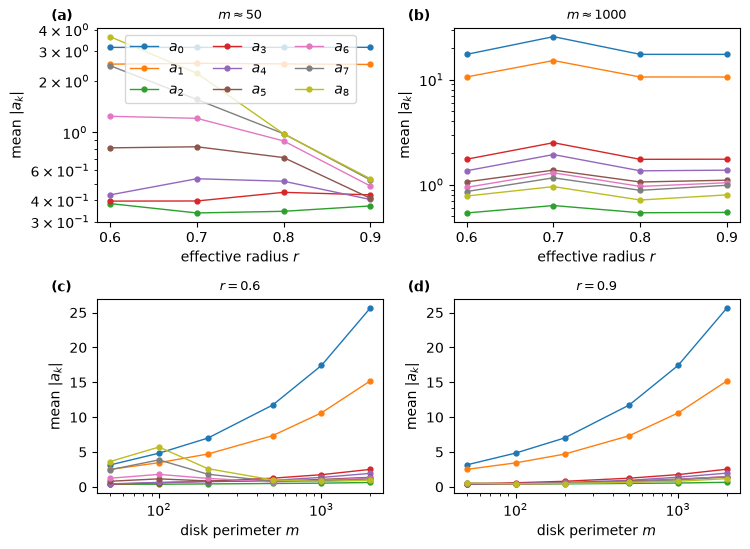

(<Figure size 760x560 with 4 Axes>,
 array([[<Axes: title={'center': '$m \\approx 50$'}, xlabel='effective radius $r$', ylabel='mean $|a_k|$'>,
         <Axes: title={'center': '$m \\approx 1000$'}, xlabel='effective radius $r$', ylabel='mean $|a_k|$'>],
        [<Axes: title={'center': '$r = 0.6$'}, xlabel='disk perimeter $m$', ylabel='mean $|a_k|$'>,
         <Axes: title={'center': '$r = 0.9$'}, xlabel='disk perimeter $m$', ylabel='mean $|a_k|$'>]],
       dtype=object))

In [9]:
plot_coefficient_magnitudes(data, m_small=50, m_large=1000, r_small=0.6, r_large=0.9)

## Residuals as a function of r and m

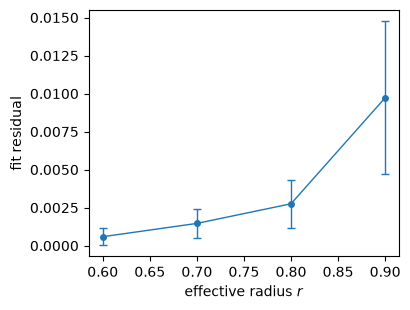

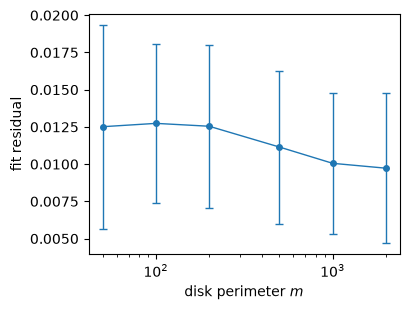

In [10]:
plot_residual_vs_radius(data, m_fixed=2000)
plot_residual_vs_perimeter(data, r_fixed=0.9)

## Mode power as a function of r and m

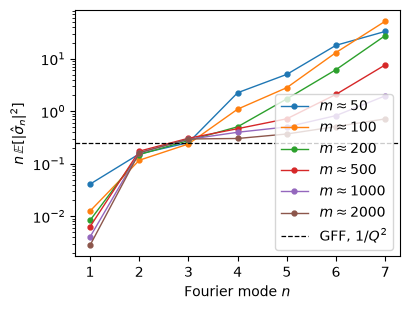

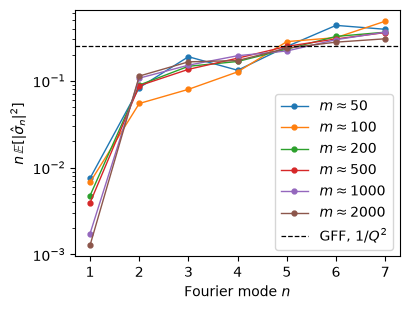

In [11]:
plot_mode_power_vs_size(data, r_fixed=0.6, n_max=7, gff_constant=0.25)
plot_mode_power_vs_size(data, r_fixed=0.9, n_max=7, gff_constant=0.25)